# 01.1 — Validate V1 + V1.5 features on map

Visual inspection of all features to sanity-check the data.

In [1]:
import sys
sys.path.insert(0, '../src')

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from estonia_landuse.data.constants import DATA_PROCESSED, CRS_ESTONIAN

In [2]:
# Load features + geometry
grid = gpd.read_file(DATA_PROCESSED / "base_grid.gpkg")
features = pd.read_parquet(DATA_PROCESSED / "features_v1.parquet")

# Merge geometry with features
gdf = grid[["cell_id", "geometry"]].merge(features, on="cell_id")
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=CRS_ESTONIAN)

print(f"{len(gdf)} cells, {len(gdf.columns)} columns")
gdf.head()

2806 cells, 20 columns


,cell_id,geometry,OBJECTID,GRD_INSPIR,TOTAL_24,land_cover_class,land_cover_group,urban_pct,agriculture_pct,grassland_pct,forest_pct,wetland_pct,water_pct,other_natural_pct,naturalness_score,carbon_score,protected_overlap_pct,distance_to_protected_m,road_density_km,building_count
0,0,"POLYGON ((446000 6537000, 446000 6538000, 4470...",4292.0,1kmN6537E0446,0.0,523,water,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,5058.359419,0.000000,0.0
1,1,"POLYGON ((447000 6536000, 447000 6537000, 4480...",4323.0,1kmN6536E0447,0.0,523,water,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,5472.689764,0.374089,0.0
2,2,"POLYGON ((447000 6537000, 447000 6538000, 4480...",4324.0,1kmN6537E0447,0.0,523,water,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,4551.190819,0.363736,6.0
3,3,"POLYGON ((447000 6538000, 447000 6539000, 4480...",4325.0,1kmN6538E0447,0.0,523,water,0.0,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.0,0.0,3671.013821,0.000000,0.0
4,4,"POLYGON ((449000 6540000, 449000 6541000, 4500...",4386.0,1kmN6540E0449,0.0,523,water,0.0,0.0,0.0,0.0,0.0,0.99,0.01,0.5,0.4,0.0,1120.280058,0.000000,0.0


## Land cover proportions

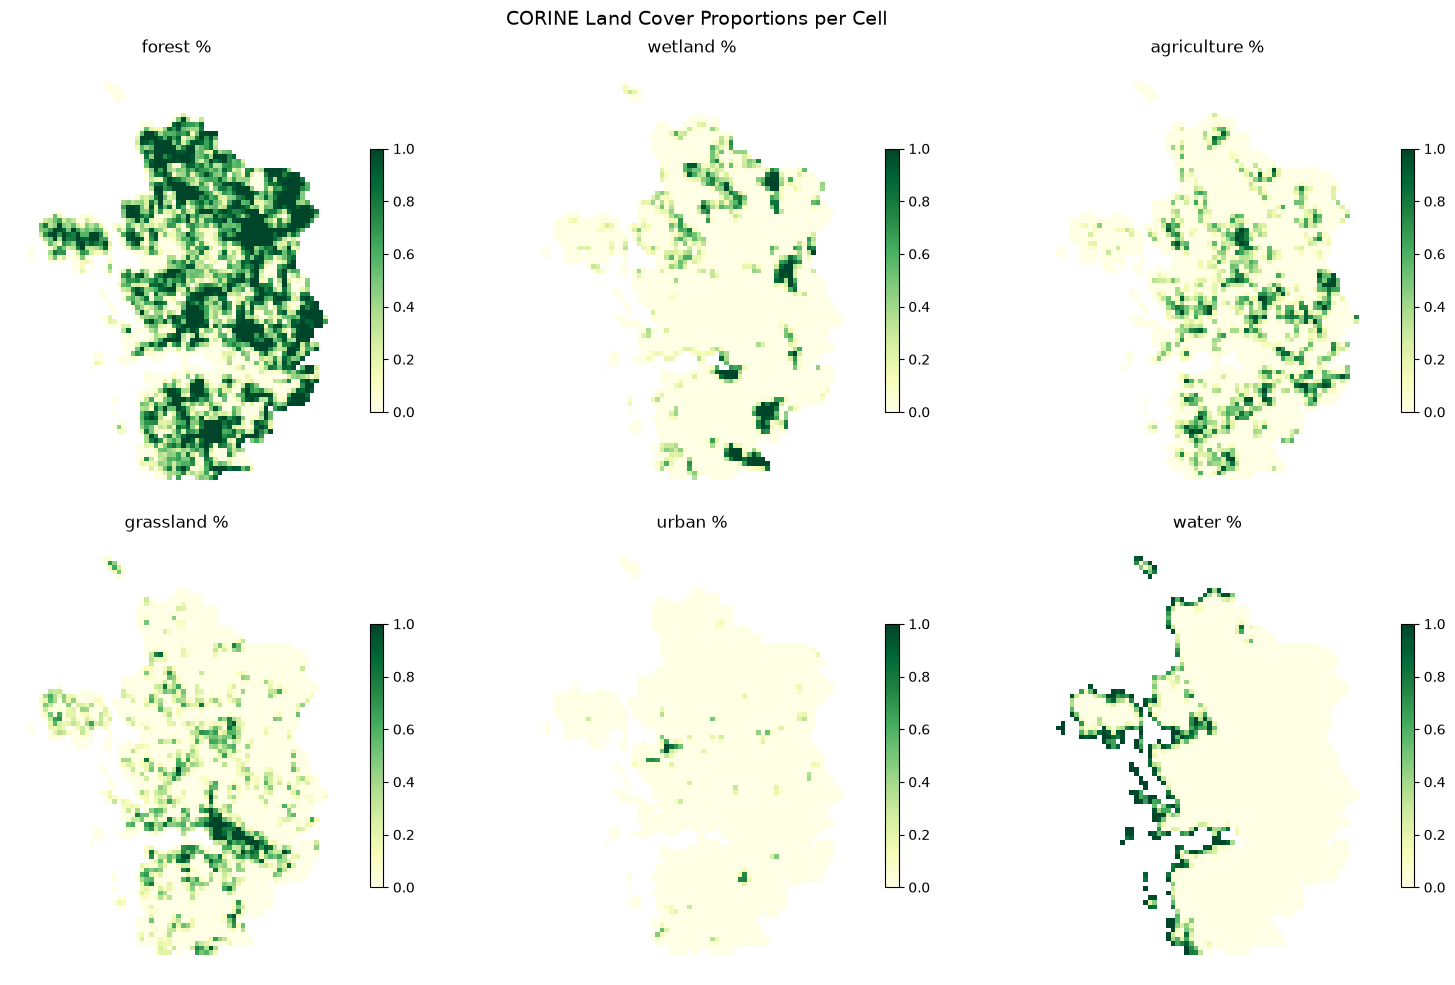

In [3]:
lc_cols = ["forest_pct", "wetland_pct", "agriculture_pct", "grassland_pct", "urban_pct", "water_pct"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, lc_cols):
    gdf.plot(column=col, ax=ax, legend=True, cmap="YlGn",
             legend_kwds={"shrink": 0.6}, vmin=0, vmax=1)
    ax.set_title(col.replace("_pct", " %"))
    ax.set_axis_off()

plt.suptitle("CORINE Land Cover Proportions per Cell", fontsize=14)
plt.tight_layout()
plt.show()

## Population and infrastructure

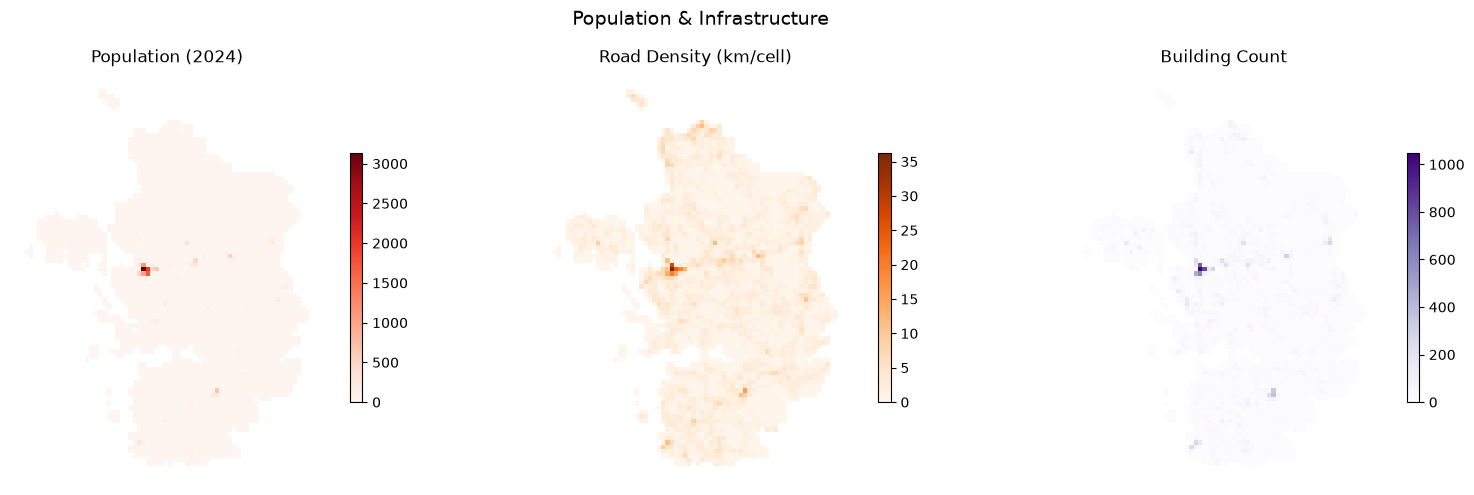

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gdf.plot(column="TOTAL_24", ax=axes[0], legend=True, cmap="Reds",
         legend_kwds={"shrink": 0.6})
axes[0].set_title("Population (2024)")
axes[0].set_axis_off()

gdf.plot(column="road_density_km", ax=axes[1], legend=True, cmap="Oranges",
         legend_kwds={"shrink": 0.6})
axes[1].set_title("Road Density (km/cell)")
axes[1].set_axis_off()

gdf.plot(column="building_count", ax=axes[2], legend=True, cmap="Purples",
         legend_kwds={"shrink": 0.6})
axes[2].set_title("Building Count")
axes[2].set_axis_off()

plt.suptitle("Population & Infrastructure", fontsize=14)
plt.tight_layout()
plt.show()

## Proxy scores and protected areas

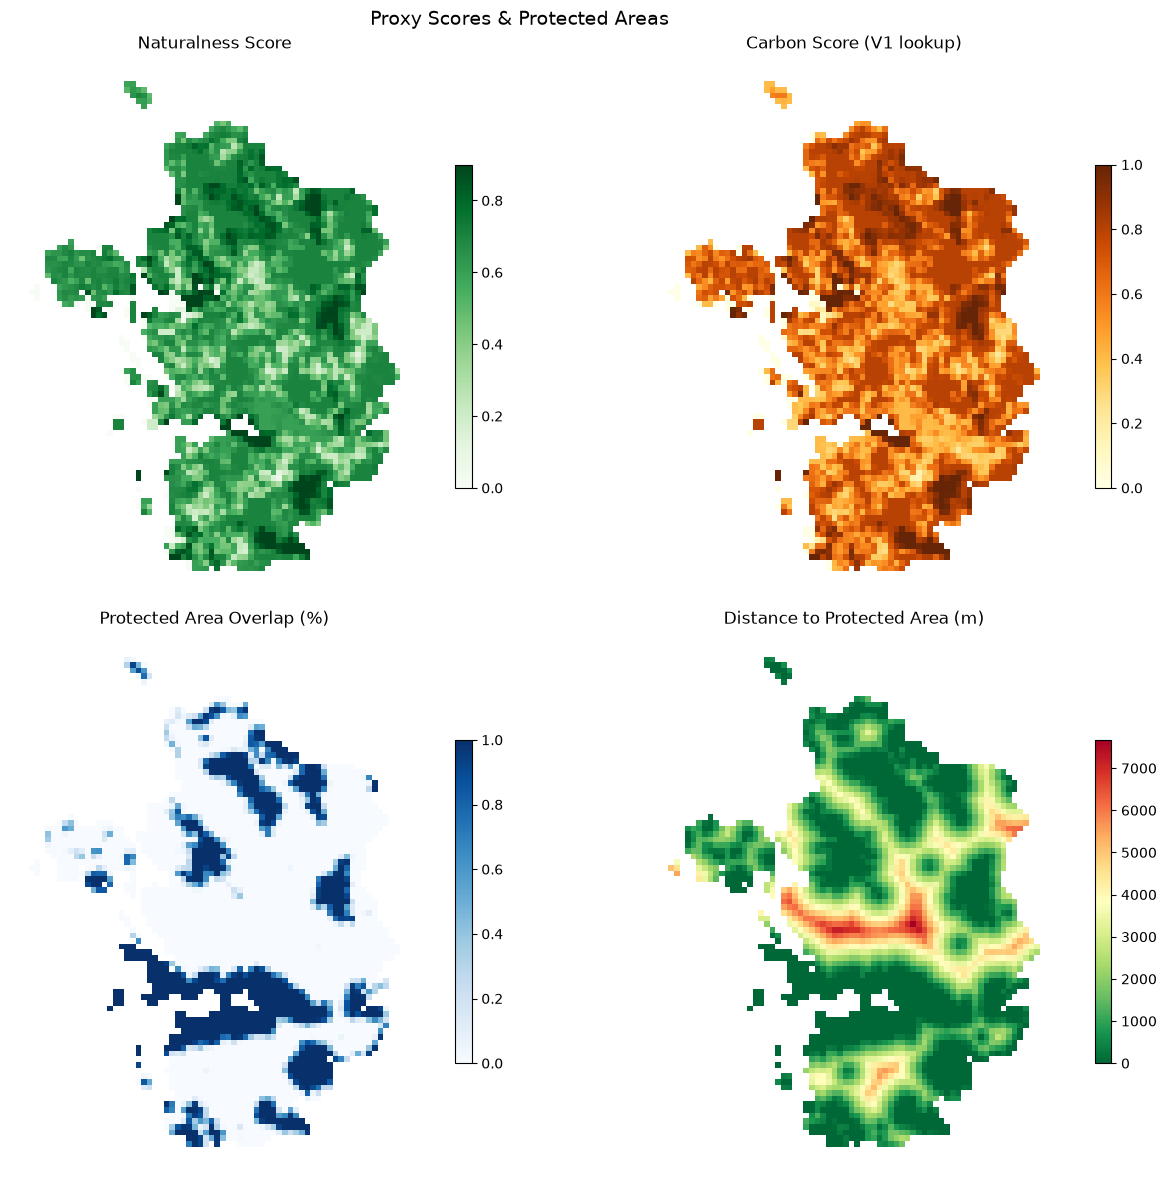

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

gdf.plot(column="naturalness_score", ax=axes[0, 0], legend=True, cmap="Greens",
         legend_kwds={"shrink": 0.6})
axes[0, 0].set_title("Naturalness Score")
axes[0, 0].set_axis_off()

gdf.plot(column="carbon_score", ax=axes[0, 1], legend=True, cmap="YlOrBr",
         legend_kwds={"shrink": 0.6})
axes[0, 1].set_title("Carbon Score (V1 lookup)")
axes[0, 1].set_axis_off()

gdf.plot(column="protected_overlap_pct", ax=axes[1, 0], legend=True, cmap="Blues",
         legend_kwds={"shrink": 0.6}, vmin=0, vmax=1)
axes[1, 0].set_title("Protected Area Overlap (%)")
axes[1, 0].set_axis_off()

gdf.plot(column="distance_to_protected_m", ax=axes[1, 1], legend=True, cmap="RdYlGn_r",
         legend_kwds={"shrink": 0.6})
axes[1, 1].set_title("Distance to Protected Area (m)")
axes[1, 1].set_axis_off()

plt.suptitle("Proxy Scores & Protected Areas", fontsize=14)
plt.tight_layout()
plt.show()

## Dominant land cover group

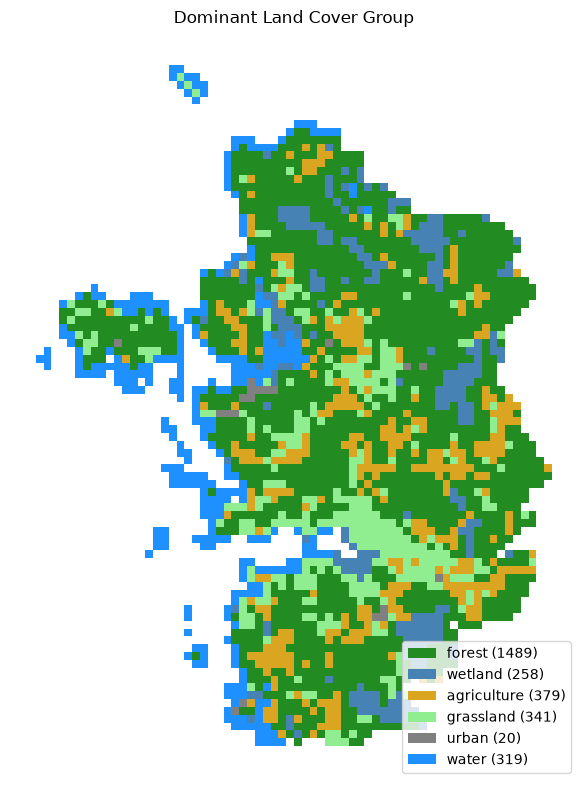

In [6]:
group_colors = {
    "forest": "#228B22",
    "wetland": "#4682B4",
    "agriculture": "#DAA520",
    "grassland": "#90EE90",
    "urban": "#808080",
    "water": "#1E90FF",
    "other_natural": "#DEB887",
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for group, color in group_colors.items():
    subset = gdf[gdf["land_cover_group"] == group]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, label=f"{group} ({len(subset)})")

ax.legend(loc="lower right")
ax.set_title("Dominant Land Cover Group")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## V1 Summary statistics

In [7]:
numeric_cols = [
    "TOTAL_24", "forest_pct", "wetland_pct", "agriculture_pct",
    "grassland_pct", "urban_pct", "water_pct",
    "naturalness_score", "carbon_score",
    "protected_overlap_pct", "distance_to_protected_m",
    "road_density_km", "building_count",
]
gdf[numeric_cols].describe().round(3)

,TOTAL_24,forest_pct,wetland_pct,agriculture_pct,grassland_pct,urban_pct,water_pct,naturalness_score,carbon_score,protected_overlap_pct,distance_to_protected_m,road_density_km,building_count
count,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000
mean,8.324,0.513,0.095,0.150,0.129,0.009,0.101,0.605,0.656,0.284,1550.196,1.399,11.837
std,87.924,0.363,0.222,0.244,0.223,0.064,0.263,0.183,0.210,0.414,1701.032,1.937,40.461
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.170,0.000,0.000,0.000,0.000,0.000,0.535,0.520,0.000,0.000,0.000,0.000
50%,0.000,0.520,0.000,0.000,0.000,0.000,0.000,0.657,0.705,0.000,992.482,1.003,0.000
75%,0.000,0.879,0.020,0.230,0.180,0.000,0.000,0.700,0.800,0.690,2601.936,2.079,11.000
max,3128.000,1.000,1.000,1.000,1.000,0.970,1.000,0.900,1.000,1.000,7671.206,36.181,1046.000


---
# V1.5 Carbon Features

Soil/peat, hydrology, and combined carbon scores from notebook 04.  
If you haven't run it yet, these sections will be skipped.

In [8]:
CARBON_DIR = Path("../data/processed/carbon_v1_5")
HAS_V15 = CARBON_DIR.exists() and (CARBON_DIR / "carbon_scores.parquet").exists()

if HAS_V15:
    soil_df = pd.read_parquet(CARBON_DIR / "soil_peat_features.parquet")
    hydro_df = pd.read_parquet(CARBON_DIR / "hydrology_features.parquet")
    scores_df = pd.read_parquet(CARBON_DIR / "carbon_scores.parquet")
    print(f"Loaded: soil ({len(soil_df.columns)} cols), hydro ({len(hydro_df.columns)} cols), scores ({len(scores_df.columns)} cols)")
else:
    print("Carbon v1.5 data not found. Run notebook 04_carbon_dataset.ipynb first.")

Loaded: soil (10 cols), hydro (13 cols), scores (13 cols)


## Soil / Peat

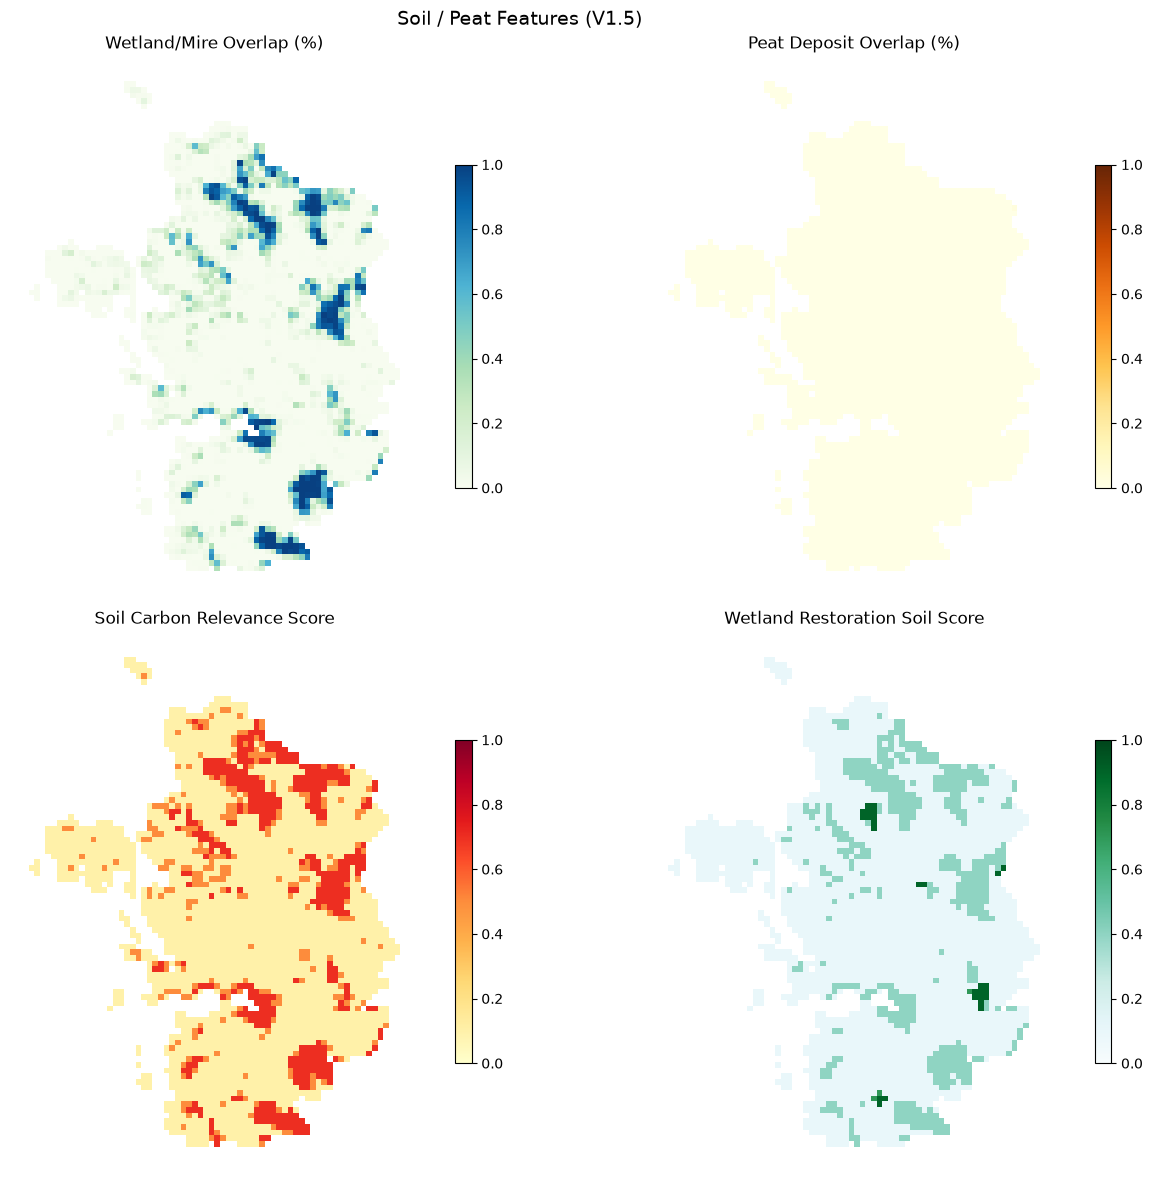

In [9]:
if HAS_V15:
    gdf_soil = grid[["cell_id", "geometry"]].merge(soil_df, on="cell_id")
    gdf_soil = gpd.GeoDataFrame(gdf_soil, geometry="geometry", crs=CRS_ESTONIAN)

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    gdf_soil.plot(column="wetland_mire_overlap_pct", ax=axes[0, 0], legend=True, cmap="GnBu",
                  legend_kwds={"shrink": 0.6}, vmin=0, vmax=1)
    axes[0, 0].set_title("Wetland/Mire Overlap (%)")
    axes[0, 0].set_axis_off()

    gdf_soil.plot(column="peat_overlap_pct", ax=axes[0, 1], legend=True, cmap="YlOrBr",
                  legend_kwds={"shrink": 0.6}, vmin=0, vmax=1)
    axes[0, 1].set_title("Peat Deposit Overlap (%)")
    axes[0, 1].set_axis_off()

    gdf_soil.plot(column="soil_carbon_relevance_score", ax=axes[1, 0], legend=True, cmap="YlOrRd",
                  legend_kwds={"shrink": 0.6}, vmin=0, vmax=1)
    axes[1, 0].set_title("Soil Carbon Relevance Score")
    axes[1, 0].set_axis_off()

    gdf_soil.plot(column="wetland_restoration_soil_score", ax=axes[1, 1], legend=True, cmap="BuGn",
                  legend_kwds={"shrink": 0.6}, vmin=0, vmax=1)
    axes[1, 1].set_title("Wetland Restoration Soil Score")
    axes[1, 1].set_axis_off()

    plt.suptitle("Soil / Peat Features (V1.5)", fontsize=14)
    plt.tight_layout()
    plt.show()

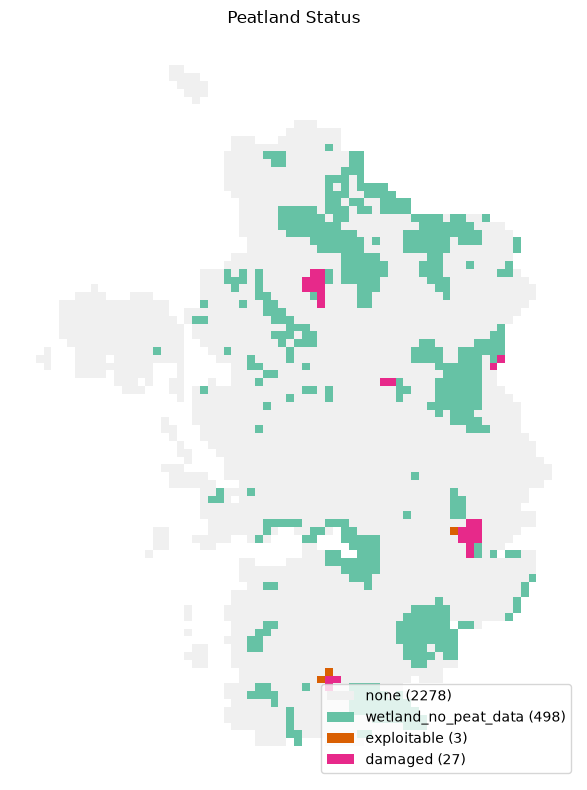

In [10]:
if HAS_V15:
    status_colors = {
        "none": "#f0f0f0",
        "wetland_no_peat_data": "#66c2a5",
        "natural": "#1b9e77",
        "exploitable": "#d95f02",
        "damaged": "#e7298a",
    }

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    for status, color in status_colors.items():
        subset = gdf_soil[gdf_soil["peatland_status"] == status]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, label=f"{status} ({len(subset)})")

    ax.legend(loc="lower right")
    ax.set_title("Peatland Status")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

## Hydrology

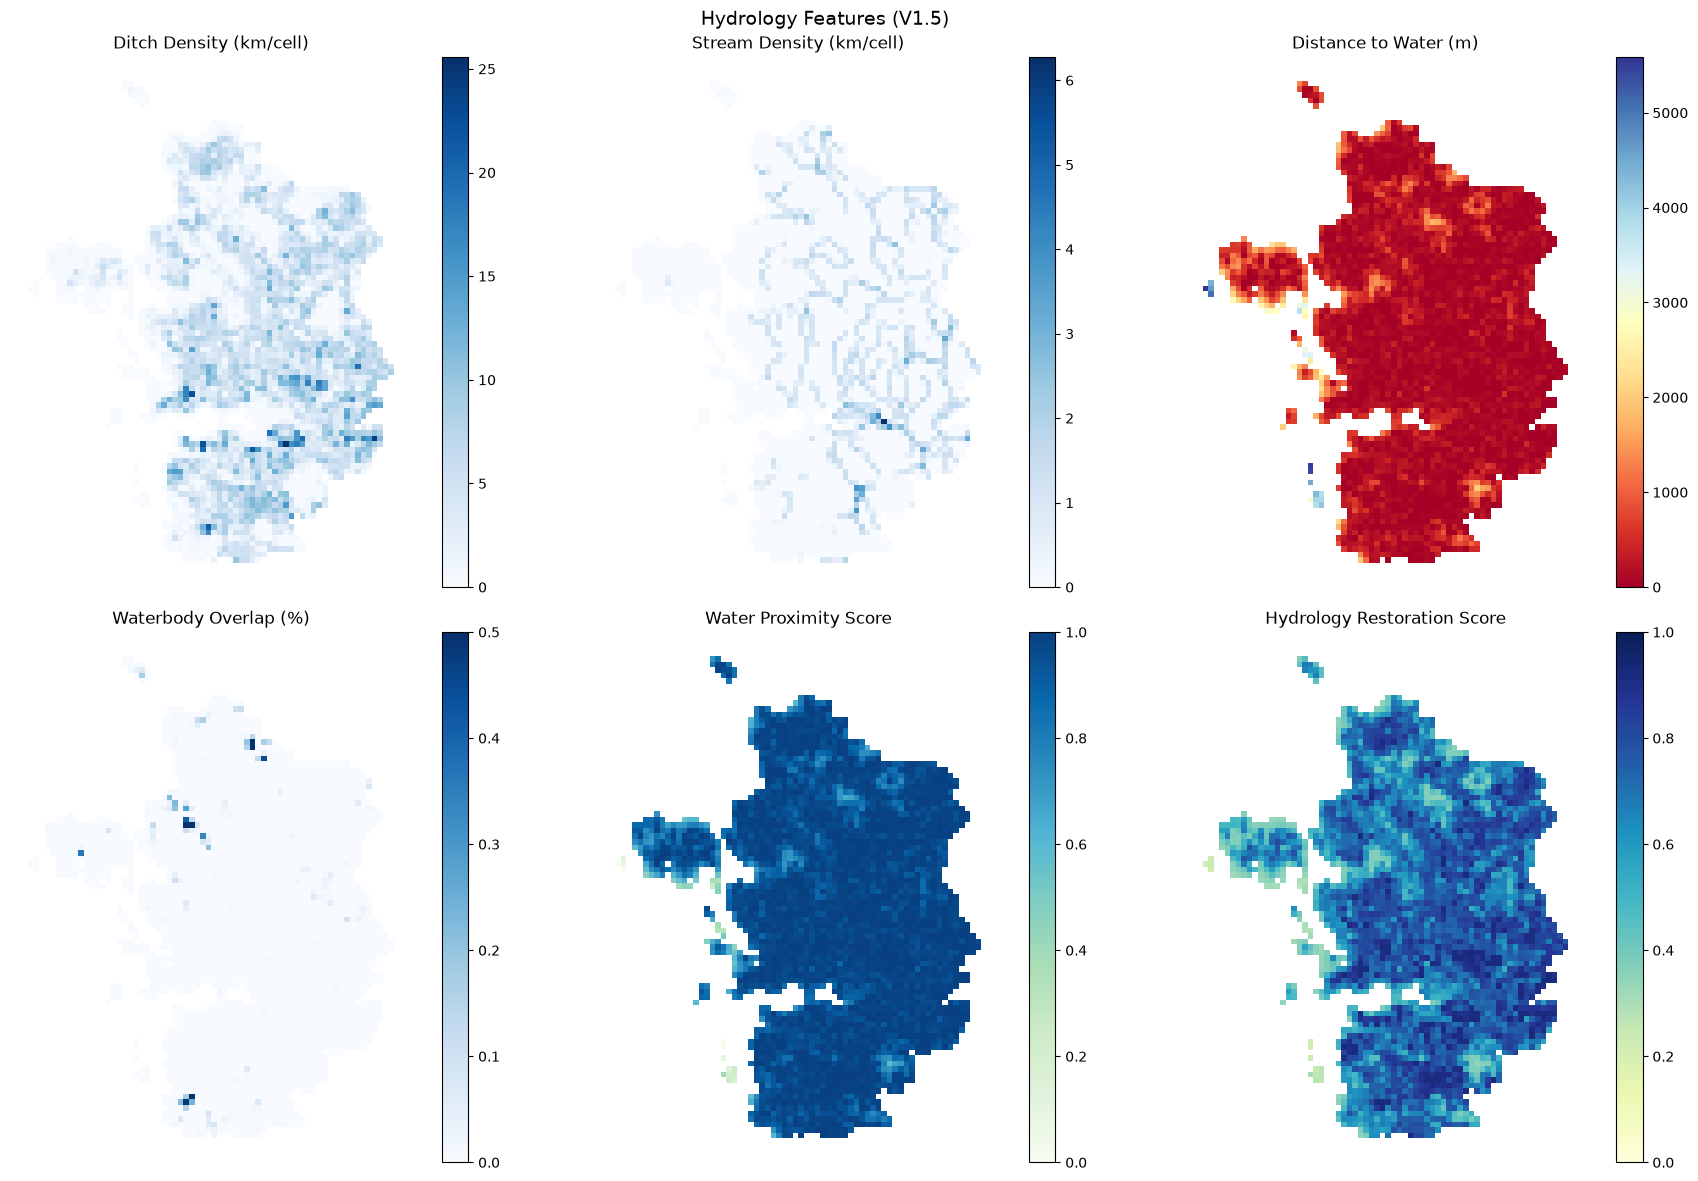

In [11]:
if HAS_V15:
    gdf_hydro = grid[["cell_id", "geometry"]].merge(hydro_df, on="cell_id")
    gdf_hydro = gpd.GeoDataFrame(gdf_hydro, geometry="geometry", crs=CRS_ESTONIAN)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    gdf_hydro.plot(column="ditch_density_1km", ax=axes[0, 0], legend=True, cmap="Blues")
    axes[0, 0].set_title("Ditch Density (km/cell)")
    axes[0, 0].set_axis_off()

    gdf_hydro.plot(column="stream_density_1km", ax=axes[0, 1], legend=True, cmap="Blues")
    axes[0, 1].set_title("Stream Density (km/cell)")
    axes[0, 1].set_axis_off()

    gdf_hydro.plot(column="distance_to_water_m", ax=axes[0, 2], legend=True, cmap="RdYlBu")
    axes[0, 2].set_title("Distance to Water (m)")
    axes[0, 2].set_axis_off()

    gdf_hydro.plot(column="waterbody_overlap_pct", ax=axes[1, 0], legend=True, cmap="Blues",
                   vmin=0, vmax=0.5)
    axes[1, 0].set_title("Waterbody Overlap (%)")
    axes[1, 0].set_axis_off()

    gdf_hydro.plot(column="water_proximity_score", ax=axes[1, 1], legend=True, cmap="GnBu",
                   vmin=0, vmax=1)
    axes[1, 1].set_title("Water Proximity Score")
    axes[1, 1].set_axis_off()

    gdf_hydro.plot(column="hydrology_restoration_score", ax=axes[1, 2], legend=True, cmap="YlGnBu",
                   vmin=0, vmax=1)
    axes[1, 2].set_title("Hydrology Restoration Score")
    axes[1, 2].set_axis_off()

    plt.suptitle("Hydrology Features (V1.5)", fontsize=14)
    plt.tight_layout()
    plt.show()

## Combined Carbon Scores

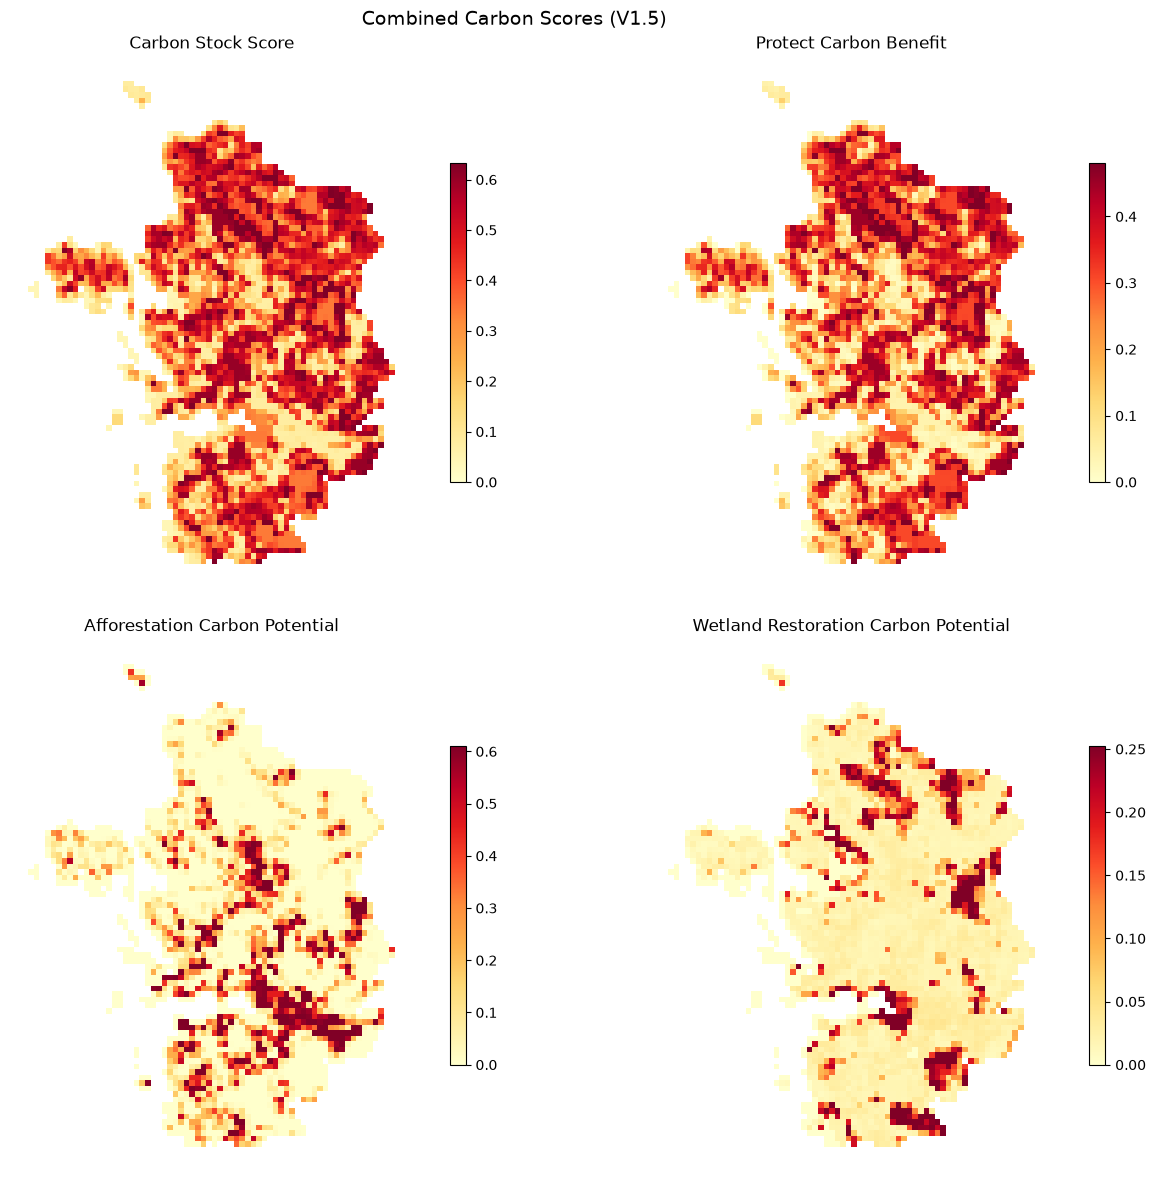

In [12]:
if HAS_V15:
    gdf_scores = grid[["cell_id", "geometry"]].merge(scores_df, on="cell_id")
    gdf_scores = gpd.GeoDataFrame(gdf_scores, geometry="geometry", crs=CRS_ESTONIAN)

    score_cols = [
        "carbon_stock_score",
        "protect_carbon_benefit",
        "afforestation_carbon_potential",
        "wetland_restoration_carbon_potential",
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for ax, col in zip(axes.flat, score_cols):
        vmax = gdf_scores[col].quantile(0.95)
        gdf_scores.plot(column=col, ax=ax, legend=True, cmap="YlOrRd",
                        legend_kwds={"shrink": 0.6}, vmin=0, vmax=max(vmax, 0.01))
        ax.set_title(col.replace("_", " ").title())
        ax.set_axis_off()

    plt.suptitle("Combined Carbon Scores (V1.5)", fontsize=14)
    plt.tight_layout()
    plt.show()

## V1.5 Summary statistics

In [13]:
if HAS_V15:
    print("=== Soil/Peat ===")
    display(soil_df.select_dtypes(include='number').describe().round(3))
    print("\n=== Hydrology ===")
    display(hydro_df.describe().round(3))
    print("\n=== Carbon Scores ===")
    display(scores_df.select_dtypes(include='number').describe().round(3))

=== Soil/Peat ===


,cell_id,peat_overlap_pct,exploitable_peat_overlap_pct,peat_extraction_overlap_pct,wetland_mire_overlap_pct,soil_carbon_relevance_score,wetland_restoration_soil_score
count,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000
mean,1402.500,0.000,0.005,0.004,0.126,0.229,0.162
std,810.167,0.001,0.051,0.050,0.254,0.230,0.137
min,0.000,0.000,0.000,0.000,0.000,0.100,0.100
25%,701.250,0.000,0.000,0.000,0.000,0.100,0.100
50%,1402.500,0.000,0.000,0.000,0.003,0.100,0.100
75%,2103.750,0.000,0.000,0.000,0.097,0.100,0.100
max,2805.000,0.027,0.999,0.923,1.000,0.700,0.900



=== Hydrology ===


,cell_id,distance_to_water_m,distance_to_river_or_stream_m,distance_to_ditch_or_drainage_m,waterbody_overlap_pct,stream_density_1km,ditch_density_1km,lowland_score,low_slope_score,water_proximity_score,wetland_neighbor_score,ditch_drainage_context_score,hydrology_restoration_score
count,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.000,2806.00,2806.000,2806.000,2806.000,2806.000
mean,1402.500,277.541,1535.879,385.603,0.005,0.296,3.784,0.779,0.75,0.945,0.364,0.352,0.698
std,810.167,497.640,1678.298,762.553,0.038,0.571,3.637,0.274,0.00,0.098,0.311,0.312,0.147
min,0.000,0.000,0.331,0.063,0.000,0.000,0.000,0.000,0.75,0.000,0.000,0.000,0.225
25%,701.250,37.192,473.868,43.870,0.000,0.000,0.506,0.714,0.75,0.940,0.068,0.049,0.618
50%,1402.500,109.596,1059.928,131.464,0.000,0.000,3.184,0.896,0.75,0.978,0.326,0.308,0.725
75%,2103.750,300.602,1999.226,376.585,0.001,0.359,5.981,0.965,0.75,0.993,0.594,0.578,0.805
max,2805.000,5589.894,15903.494,7908.722,0.820,6.278,25.583,1.000,0.75,1.000,1.000,1.000,0.925



=== Carbon Scores ===


,cell_id,carbon_stock_score,protect_carbon_benefit,afforestation_carbon_potential,wetland_restoration_carbon_potential,score_no_change_carbon,score_protect_carbon,score_restore_wetland_carbon,score_afforest_carbon,carbon_model_uncertainty_score
count,2806.000,2806.000,2806.000,2806.000,2806.000,2806.0,2806.000,2806.000,2806.000,2806.000
mean,1402.500,0.367,0.254,0.131,0.057,0.0,0.254,0.057,0.131,0.245
std,810.167,0.188,0.155,0.199,0.080,0.0,0.155,0.080,0.199,0.052
min,0.000,0.040,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.146
25%,701.250,0.203,0.110,0.000,0.016,0.0,0.110,0.016,0.000,0.212
50%,1402.500,0.389,0.275,0.016,0.023,0.0,0.275,0.023,0.016,0.250
75%,2103.750,0.523,0.383,0.188,0.038,0.0,0.383,0.038,0.188,0.275
max,2805.000,0.796,0.627,0.700,0.397,0.0,0.627,0.397,0.700,0.400
